# Plot Supertrend markers with Altair

This example computes Bartons' `SUPERTREND` expression over the bundled daily prices, builds monochrome candlesticks from Altair rule and bar marks, and overlays bullish and bearish Supertrend dots.

In [1]:
from typing import cast

import altair as alt
import polars as pl

alt.renderers.enable("svg")

from bartons.samples import sample_prices
from bartons.indicators import SUPERTREND


## Compute Supertrend

`SUPERTREND` returns a struct containing the trend value and direction. Unnesting it makes both fields directly available to Altair.

In [2]:
prices = sample_prices("daily")

prices = prices.with_columns(SUPERTREND()).unnest()

prices

date,open,high,low,close,volume,supertrend,direction
date,f64,f64,f64,f64,i64,f64,i64
1980-12-12,0.099058,0.099488,0.099058,0.099058,469033600,null,null
1980-12-15,0.09432,0.09432,0.09389,0.09389,175884800,null,null
1980-12-16,0.087429,0.087429,0.086999,0.086999,105728000,null,null
1980-12-17,0.089152,0.089582,0.089152,0.089152,86441600,null,null
1980-12-18,0.091737,0.092167,0.091737,0.091737,73449600,null,null
…,…,…,…,…,…,…,…
2024-08-05,199.089996,213.5,196.0,209.270004,119548600,226.945263,-1
2024-08-06,205.300003,209.990005,201.070007,207.229996,69660500,226.945263,-1
2024-08-07,206.899994,213.639999,206.389999,209.820007,63516400,226.945263,-1


## Layer candles and Supertrend dots

Each wick is a rule from low to high. Each body is a bar from open to close: rising candles are hollow and falling candles are filled black. Green and red dots mark bullish and bearish Supertrend values.

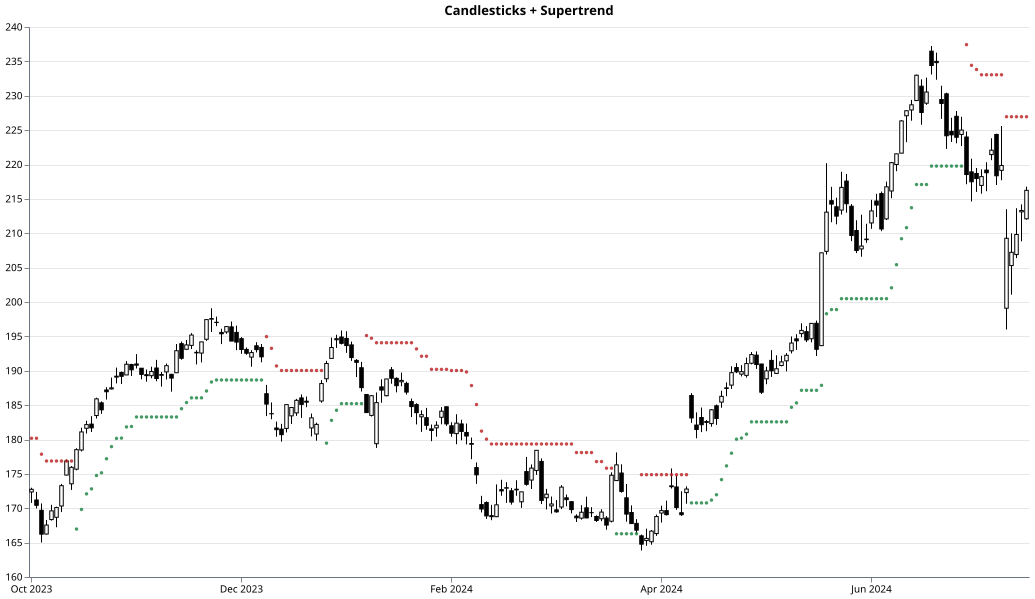

In [3]:
def plot_chart(prices: pl.DataFrame, max_bars: int = 200) -> alt.LayerChart:
    if max_bars > 0:
        prices = prices.tail(max_bars)

    tick_values = prices["date"].to_list()[::42]

    x = alt.X(
        "yearmonthdate(date):O",
        title=None,
        axis=alt.Axis(
            values=tick_values,
            format="%b %Y",
        ),
    )

    price_scale = alt.Scale(zero=False)
    base = alt.Chart(prices).encode(x=x)


    wicks = cast(alt.Chart, base.mark_rule(color="black", strokeWidth=1)).encode(
        y=alt.Y("low:Q", title=None, scale=price_scale),
        y2="high:Q",
    )

    bodies = cast(
        alt.Chart,
        base.mark_bar(width={"band": 0.7}, stroke="black", strokeWidth=1),
    ).encode(
        y=alt.Y("open:Q", title=None, scale=price_scale),
        y2="close:Q",
        fill=alt.condition(
            alt.datum.close >= alt.datum.open,
            alt.value("white"),
            alt.value("black"),
        ),
    )

    supertrend = cast(alt.Chart, base.mark_circle(size=12, opacity=0.8)).encode(
        y=alt.Y("supertrend:Q"),
        color=alt.condition(
            alt.datum.direction == 1,
            alt.value("#15803d"),
            alt.value("#b91c1c"),
        ),
    )

    chart = (wicks + bodies + supertrend).properties(
        title="Candlesticks + Supertrend",
        width=1000,
        height=550,
    ).configure_view(stroke=None).configure_axis(
        gridColor="#e5e7eb",
        domainColor="#6b7280",
    )
    
    return cast(alt.LayerChart, chart)


plot_chart(prices)